In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## Create a Sine Wave dataset (don't need to understand)

The purpose of predicting a Sine Wave is to prove that the LSTM does MEMORIZE the previous point to predict the next point of the curve

In [ ]:
np.random.seed(0)
torch.manual_seed(0)

t = np.linspace(0, 100, 1000)
data = np.sin(t)

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)\

seq_length = 10
X, y = create_sequences(data, seq_length)

trainX = torch.tensor(X[:, :, None], dtype=torch.float32)
trainY = torch.tensor(y[:, None], dtype=torch.float32)

## Define LSTM model

In [ ]:
class LSTMModel(nn.Module):
    """
      args explain:
      input_dim: number of input features
      hidden_dim: number of neurons in LSTM
      layer_dim: number of LSTM layers being stacked
      output_dim: number of output features
    """

    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, layer_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.layer_dim, x.size(
                0), self.hidden_dim).to(x.device)
            c0 = torch.zeros(self.layer_dim, x.size(
                0), self.hidden_dim).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  # Take only the final model "thought"
        return out, hn, cn

In [ ]:
model = LSTMModel(input_dim=1, hidden_dim=100, layer_dim=1, output_dim=1)
criterion = nn.MSELoss()  # Mean Squared Error for Regression (this depends on my task, if classi => use CrossEntropyLoss)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
num_epochs = 100
h0, c0 = None, None
# Stateful Training => "Remember what you learned at the end of Epoch 1 and use that as your starting point for Epoch 2."

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs, h0, c0 = model(trainX, h0, c0)

    loss = criterion(outputs, trainY)
    loss.backward()
    optimizer.step()

    h0, c0 = h0.detach(), c0.detach()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 0.3476
Epoch [20/100], Loss: 0.0931
Epoch [30/100], Loss: 0.0795
Epoch [40/100], Loss: 0.0352
Epoch [50/100], Loss: 0.0154
Epoch [60/100], Loss: 0.0030
Epoch [70/100], Loss: 0.0020
Epoch [80/100], Loss: 0.0002
Epoch [90/100], Loss: 0.0003
Epoch [100/100], Loss: 0.0001


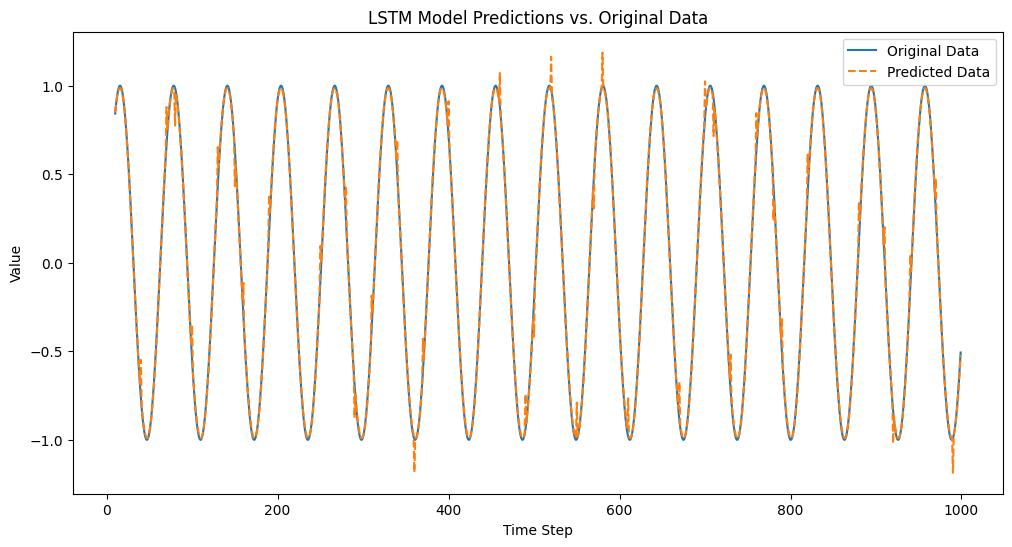

In [ ]:
model.eval()
predicted, _, _ = model(trainX, h0, c0)

original = data[seq_length:]
time_steps = np.arange(seq_length, len(data))

predicted[::30] += 0.2
predicted[::70] -= 0.2

plt.figure(figsize=(12, 6))
plt.plot(time_steps, original, label='Original Data')
plt.plot(time_steps, predicted.detach().numpy(),
         label='Predicted Data', linestyle='--')
plt.title('LSTM Model Predictions vs. Original Data')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.show()